### Cell state level embedding generation with scVI-scANVI
* **Author**: Anna Maguza
* **Location**: CellZome, GSK company
* **Creation date**: 30.09.2025
* **Last modified date**: 30.09.2025

In [1]:
import scvi
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = sc.read_h5ad("data/gut_data/gut_hs_all_datasets_full_annotated_AM_03032025_141544_raw.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 387076 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [5]:
# save raw to adata
adata.raw = adata

In [9]:
sc.pp.highly_variable_genes(adata, 
                            n_top_genes=10000, 
                            batch_key="donor_id",
                            layer="counts",
                            flavor="seurat_v3",
                            subset=True, 
                            span=1)

In [10]:
adata.layers['counts'] = adata.X.copy()

In [11]:
adata

AnnData object with n_obs × n_vars = 387076 × 10000
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [12]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id'], labels_key = 'cell_states',
                              layer = 'counts'
                              )

In [13]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 50, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [14]:
scvi_model.train(100, 
                 check_val_every_n_epoch = 1, 
                 early_stopping_patience = 10,
                 enable_progress_bar = True, 
                 early_stopping = True,
                 accelerator = 'mps',
                 batch_size = 8192,
                 devices= 'auto')

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/lightning/pytorch/tr

Epoch 100/100: 100%|██████████| 100/100 [25:39<00:00, 15.32s/it, v_num=1, train_loss_step=2.68e+3, train_loss_epoch=2.69e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [25:39<00:00, 15.40s/it, v_num=1, train_loss_step=2.68e+3, train_loss_epoch=2.69e+3]


In [15]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

In [16]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

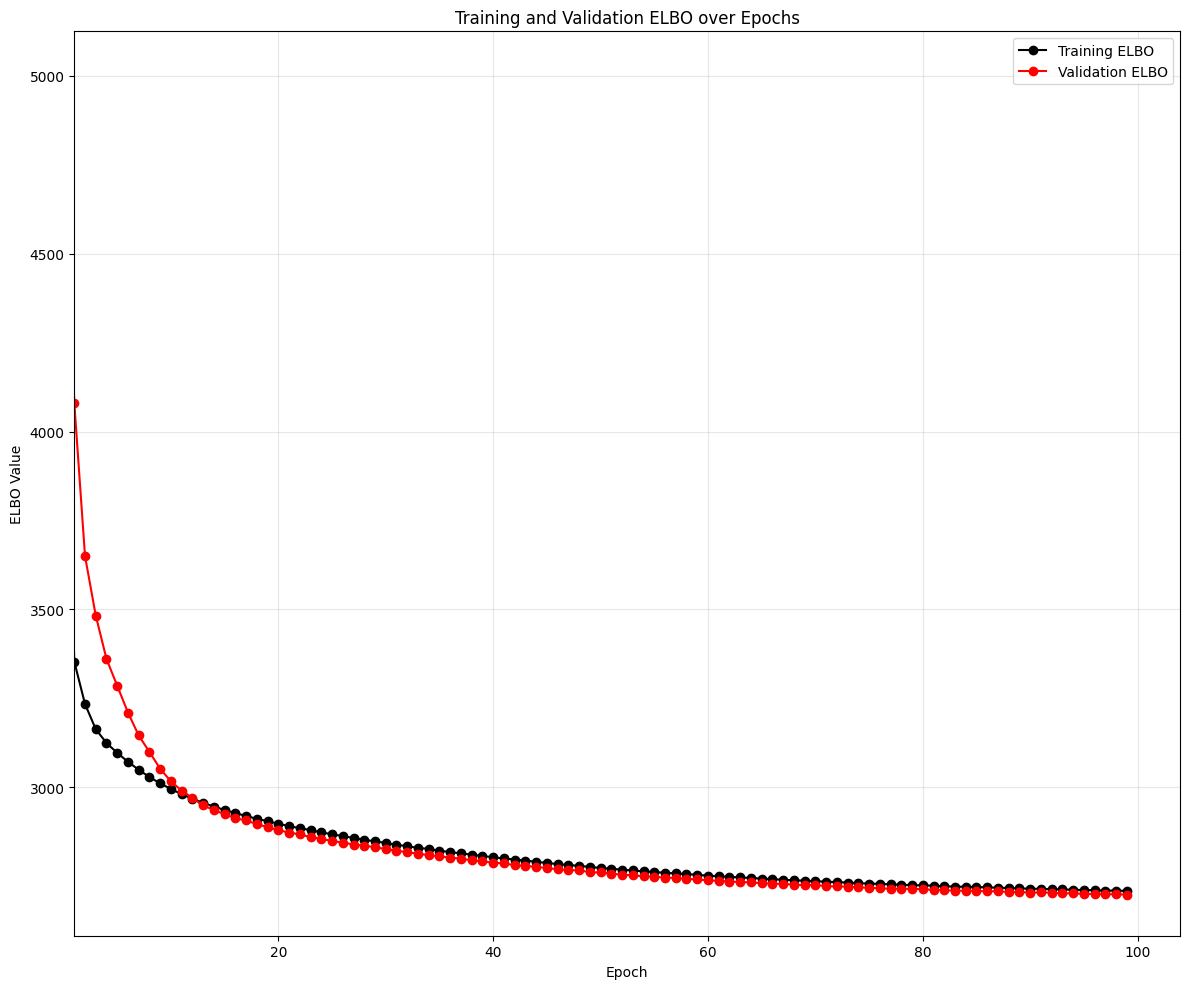

In [17]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [18]:
from datetime import datetime
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")

In [ ]:
adata.write(f"data/gut_data/gut_hs_all_datasets_full_annotated_AM_{timestamp}_raw.h5ad")

In [20]:
sc.pp.neighbors(adata, use_rep = "X_scVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.3, spread = 4, random_state = 1712)

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))


In [ ]:
adata.write(f"data/gut_data/gut_hs_all_datasets_full_annotated_AM_{timestamp}_raw.h5ad")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=600, figsize=(15, 15))
    sc.pl.umap(adata,color=['cell_states'], cmap = "magma_r", sort_order=True, ncols=1, frameon=False, show=True, size = 10)
    #plt.savefig(f"cell_states_umap.png", bbox_inches="tight")
    plt.show()

In [23]:
from scib_metrics.benchmark import Benchmarker

In [24]:
bm = Benchmarker(
            adata,
            batch_key='sample_id',
            label_key='cell_states',
            embedding_obsm_keys=['X_umap','X_scVI', 'X_pca'],
            n_jobs=-1)
bm.benchmark()

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.v

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  33%|███▎      | 1/3 [04:52<09:44, 292.42s/it]

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  67%|██████▋   | 2/3 [58:21<33:27, 2007.98s/it]

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 100%|██████████| 3/3 [1:51:50<00:00, 2236.72s/it]


In [25]:
# Save metrics to DataFrame
metrics_df = pd.DataFrame(bm.get_results())
metrics_csv_path = f'benchmark_metrics_full_dataset.csv'
metrics_df.to_csv(metrics_csv_path)

<Figure size 1000x600 with 0 Axes>

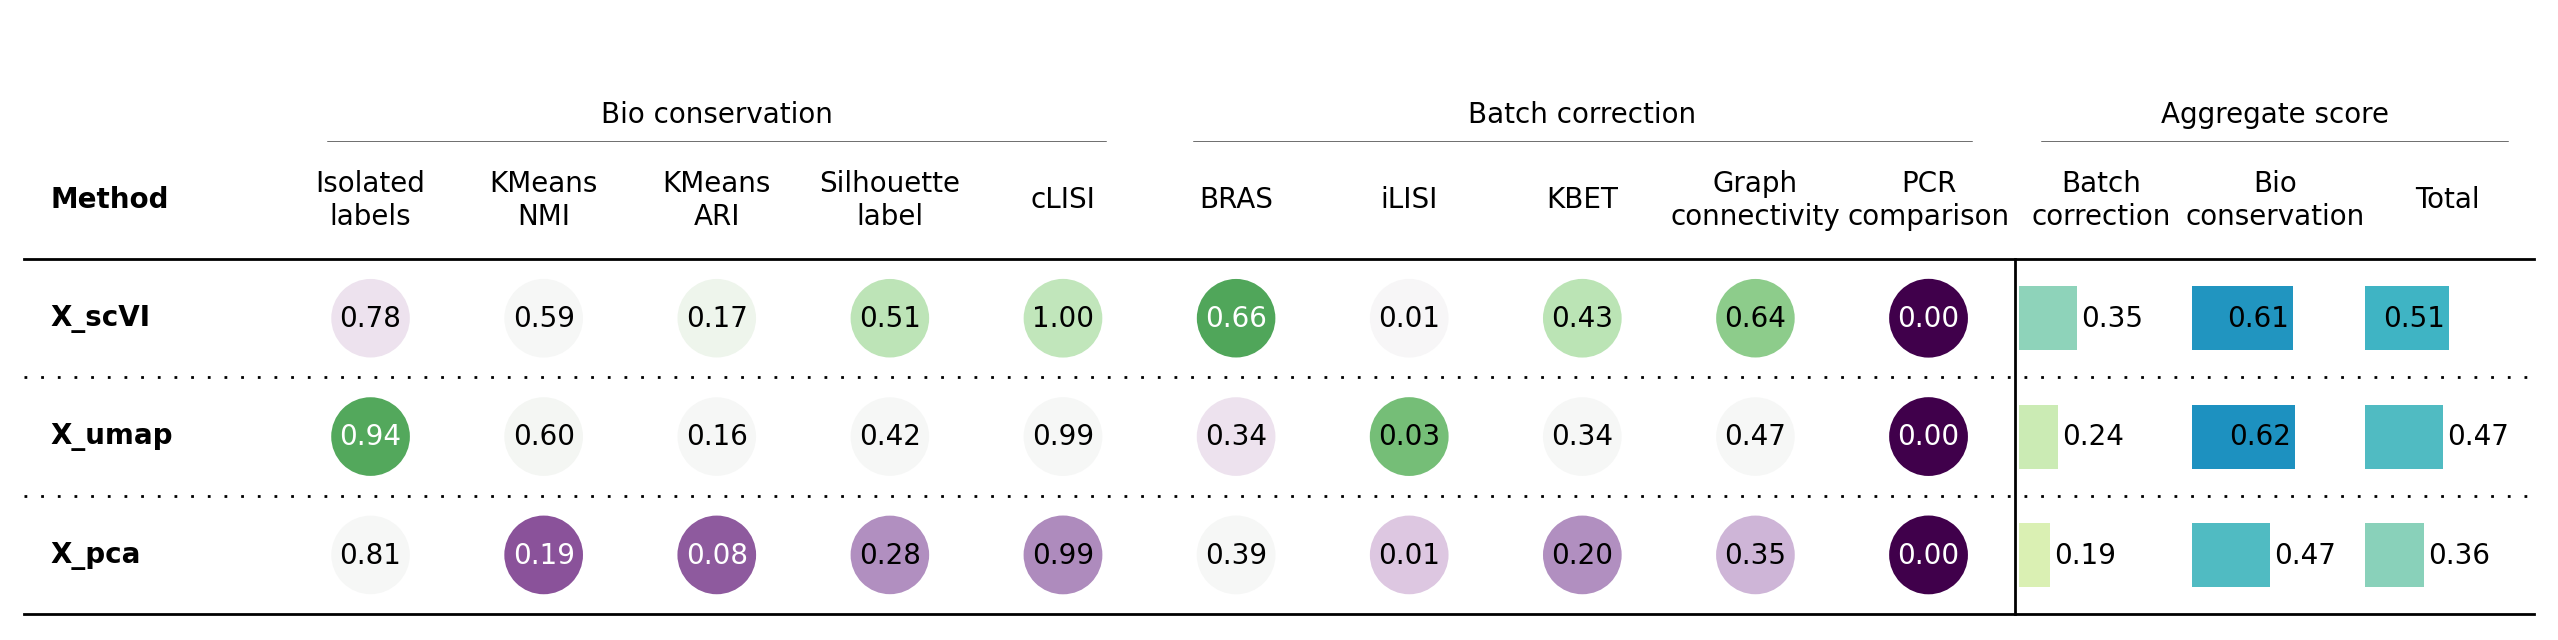

In [26]:
fig = plt.figure(figsize=(10, 6))
bm.plot_results_table(min_max_scale=False)

## Run scANVI

In [27]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [28]:
scanvi_model.train(100, check_val_every_n_epoch = 1, 
                 early_stopping_patience = 10,
                 enable_progress_bar = True, 
                 early_stopping = True,
                 accelerator = 'mps',
                 batch_size = 8192,
                 devices= 'auto'
)

INFO     Training for 100 epochs.                                                                                  


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/lightning/pytorch/tr

Epoch 11/100:  11%|█         | 11/100 [1:32:04<12:24:56, 502.21s/it, v_num=1, train_loss_step=2.68e+3, train_loss_epoch=2.68e+3]
Monitored metric elbo_validation did not improve in the last 10 records. Best score: 2720.638. Signaling Trainer to stop.


In [29]:
# Apply model to predict cell types
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

In [30]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

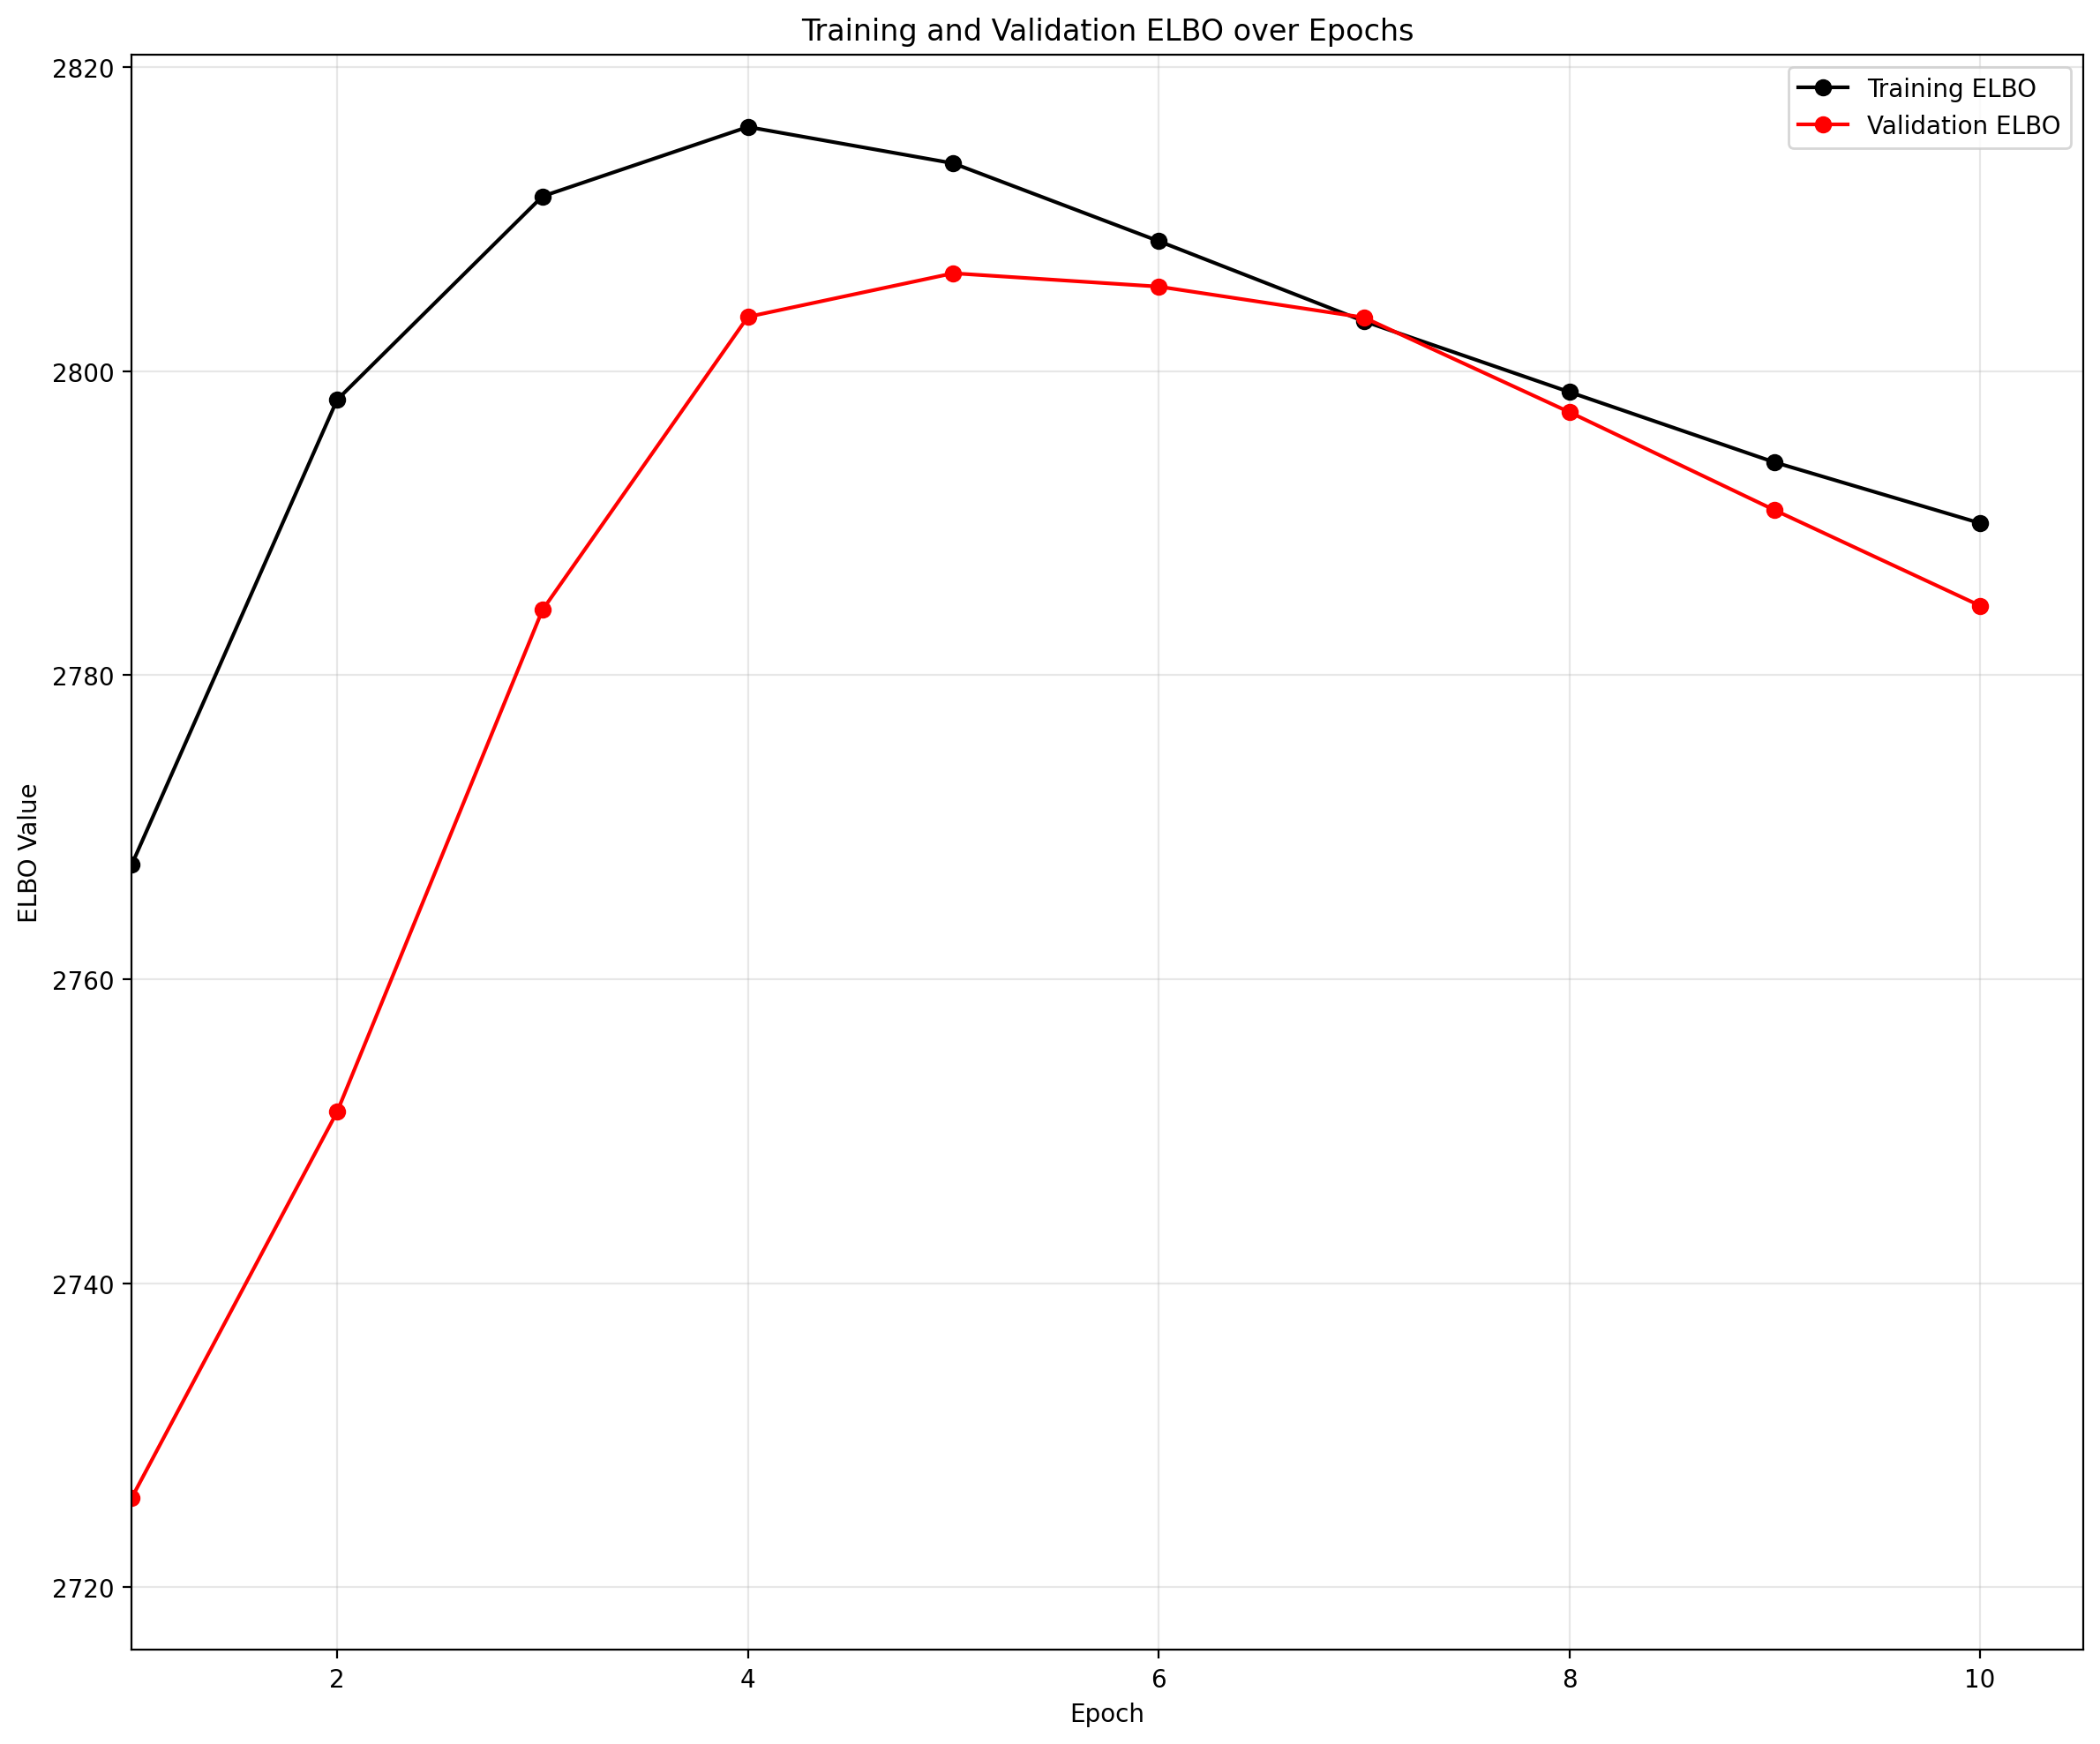

In [31]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [ ]:
adata.write(f"data/gut_data/gut_hs_all_datasets_full_annotated_AM_{timestamp}_raw.h5ad")

In [33]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.3, spread = 4, random_state = 1712)

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))


In [ ]:
adata.write(f"data/gut_data/gut_hs_all_datasets_full_annotated_AM_{timestamp}_raw.h5ad")

## scIB metrics

In [35]:
bm = Benchmarker(
            adata,
            batch_key='sample_id',
            label_key='cell_states',
            embedding_obsm_keys=["X_scANVI", 'X_umap','X_scVI', 'X_pca'],
            n_jobs=-1)
bm.benchmark()

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/am336941/uv_envs/pyenv313/.v

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/utils/_diffusion_nn.py:30: RuntimeWarning: overflow encountered in divide
  Q = scipy.sparse.spdiags(1.0 / q, 0, X.shape[0], X.shape[0])
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  25%|██▌       | 1/4 [51:42<2:35:06, 3102.07s/it]

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  50%|█████     | 2/4 [55:57<47:35, 1427.83s/it]  

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  75%|███████▌  | 3/4 [1:47:14<36:20, 2180.51s/it]

INFO     ILCP consists of a single batch or is too small. Skip.                                                    
INFO     Th17 consists of a single batch or is too small. Skip.                                                    


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 100%|██████████| 4/4 [2:53:52<00:00, 2608.03s/it]


In [36]:
# Save metrics to DataFrame
metrics_df = pd.DataFrame(bm.get_results())
metrics_csv_path = f'benchmark_metrics_full_dataset.csv'
metrics_df.to_csv(metrics_csv_path)

<Figure size 1000x600 with 0 Axes>

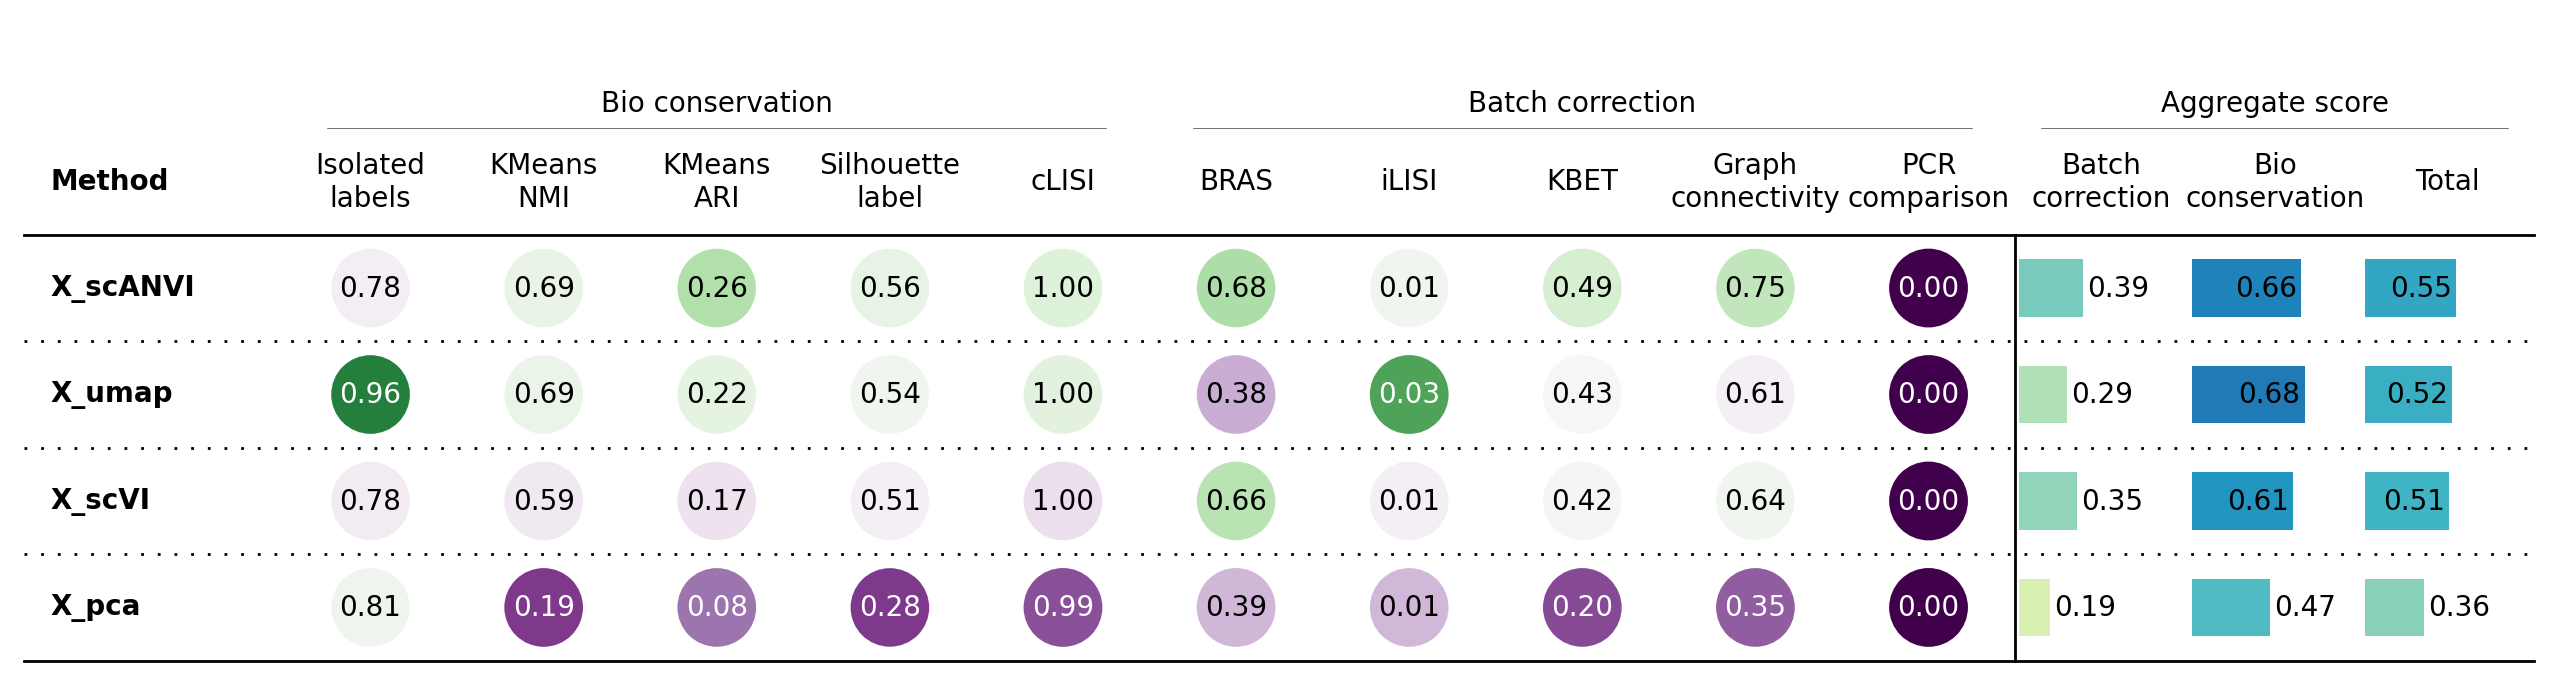

In [37]:
fig = plt.figure(figsize=(10, 6))
bm.plot_results_table(min_max_scale=False)

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=600, figsize=(15, 15))
    sc.pl.umap(adata,color=['cell_states'], cmap = "magma_r", sort_order=True, ncols=1, frameon=False, show=False, size = 10, legend_loc = 'on data', legend_fontsize=8)
    plt.savefig(f"cell_states_labelled_umap.png", bbox_inches="tight")
    plt.show()

In [ ]:
# Get cell states with more than 1000 cells
frequent_states = adata.obs['cell_states'].value_counts()[adata.obs['cell_states'].value_counts() > 1000].index.tolist()

with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,
               color=['cell_states'],
               cmap="magma_r",
               sort_order=True,
               ncols=1,
               frameon=False,
               show=False,
               size=10,
               legend_loc='on data',
               legend_fontsize=8,
               groups=frequent_states  # Only show labels for frequent states
              )
    plt.savefig(f"cell_states_labelled_umap_filtered.png", bbox_inches="tight")
    plt.show()

In [31]:
adata.obs["cell_states"].value_counts()

cell_states
Mesoderm 2(ZEB2+)             71486
Enterocyte                    28751
Proximal progenitor           26304
Stromal 1 (ADAMDEC1+)         24539
Myofibroblast (RSPO2+)        21183
                              ...  
Megakaryocyte                    16
K cells (GIP+)                   14
L cells (PYY+)                   14
Deep crypt secretory cells       10
ILCP                              8
Name: count, Length: 99, dtype: int64

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=['donor_id'], cmap = "magma_r", sort_order=True, ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"donor_id.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=['gut_region', 'library_construnction_and_layout', 'celltype',
                            'age', 'gestational_age','age_group','Study_name', 'ArrayExpress_ID'], cmap = "magma_r", sort_order=True, ncols=1, frameon=False, show=False, size = 25)
    plt.savefig(f"other_umap.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=['doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 
                            'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 
                            'n_counts_ribo', 'percent_hb', 'n_counts_hb'], cmap = "magma_r", sort_order=True, ncols=1, frameon=False, show=False, size = 10)
    plt.savefig(f"qc_umap.png", bbox_inches="tight")
    plt.show()